<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/13_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
!gdown 1EaY4IGoRpcxv1nIidrHbkduOmWVplkh2

Downloading...
From: https://drive.google.com/uc?id=1EaY4IGoRpcxv1nIidrHbkduOmWVplkh2
To: /content/Telco-Customer-Churn.csv
100% 978k/978k [00:00<00:00, 41.6MB/s]


In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
data = pd.get_dummies(df.drop(columns="customerID"), drop_first=True, dtype=int)
data.shape

(7043, 31)

In [ ]:
data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [ ]:
y = data.pop("Churn_Yes")
X = data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X.shape

(7043, 30)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
y.mean().round(3)

np.float64(0.265)

In [ ]:
# Treat churn as a number (0/1) and fit linear reg. model
linear = LinearRegression()
linear.fit(X_train[["tenure", "MonthlyCharges"]], y_train)
y_pred_linear = linear.predict(X_test[["tenure", "MonthlyCharges"]])

In [ ]:
y_pred_linear[:10]

array([ 0.1848822 ,  0.61051949,  0.26076535,  0.43552138,  0.04365529,
        0.51001372,  0.50686535,  0.1845699 , -0.15534665,  0.29405097])

In [ ]:

print("Lowest prediction     :", y_pred_linear.min().round(3))
print("Impossible (below 0)  :", (y_pred_linear < 0).sum(), "of", len(y_pred_linear))

Lowest prediction     : -0.241
Impossible (below 0)  : 159 of 1409


In [ ]:
y_pred_linear.max()

np.float64(0.6745182091032591)

In [ ]:
def sigmoid(z):
    return 1/(1+ np.exp(-z))

In [ ]:
sigmoid(0)

np.float64(0.5)

In [ ]:
sigmoid(1)

np.float64(0.7310585786300049)

In [ ]:
sigmoid(-0.88)

np.float64(0.29317777890643243)

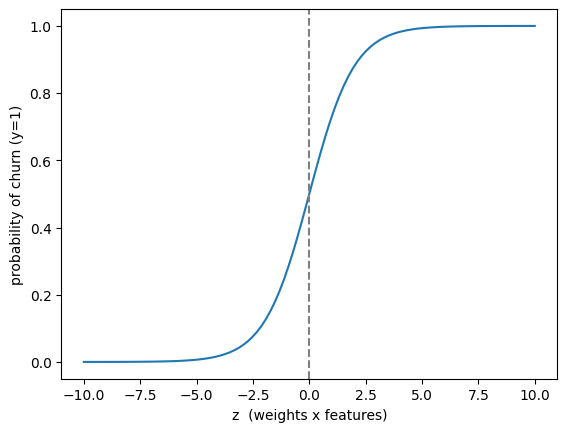

In [ ]:
z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("z  (weights x features)")
plt.ylabel("probability of churn (y=1)")
plt.show()

In [ ]:
sigmoid(100)

np.float64(1.0)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train) # it's learning the parameters/weights/coeff of the best seprator line

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
print(model.coef_.round(2))
print(model.intercept_[0])

[[ 0.21 -0.05  0.    0.    0.04  0.04 -0.23 -0.4   0.18  0.26  0.57 -0.11
  -0.11 -0.57 -0.11 -0.24 -0.11 -0.11 -0.11 -0.54 -0.11  0.17 -0.11  0.17
  -0.41 -0.6   0.43 -0.14  0.27 -0.05]]
-0.2250673318290526


In [ ]:
# w1.x1 + w2.x2 + w3.x3 + ..... w30.x30 + w0
# w.T x + w0

In [ ]:
x_query = X_test.iloc[0].values
x_query

array([0.0000e+00, 7.2000e+01, 1.1405e+02, 8.4682e+03, 1.0000e+00,
       1.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
       1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
       0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       1.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00])

In [ ]:
# model.coef_[0]

In [ ]:
z = np.sum(model.coef_[0] * x_query) + model.intercept_[0]
z

np.float64(-2.8727246036934844)

In [ ]:
sigmoid(z) # prob of churn y=1

np.float64(0.05351847125618225)

In [ ]:
model.predict_proba([x_query]).round(3)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.946, 0.054]])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Predicted:", y_pred[:20])
print("Acutal:", y_test[:20].values)

Predicted: [0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]
Acutal: [0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0]


In [ ]:
# accuracy is calculated.
(y_pred == y_test).mean()

np.float64(0.8041163946061036)

In [ ]:
accuracy_score(y_test,  y_pred)

0.8041163946061036

In [ ]:
pd.DataFrame({
    "probability": model.predict_proba(X_test)[:, 1].round(3),
    "predicted": model.predict(X_test),
    "actual": y_test.values,
}).head(8)


,probability,predicted,actual
0,0.054,0,0
1,0.666,1,0
2,0.071,0,0
3,0.340,0,0
4,0.032,0,0
5,0.580,1,0
6,0.415,0,0
7,0.135,0,0


In [ ]:
# What does the sigmoid guarantee?

In [ ]:
model.coef_[0]

array([ 2.12330453e-01, -5.28112143e-02,  3.96975296e-03,  2.15700851e-04,
        4.13609725e-02,  3.90211696e-02, -2.31917319e-01, -3.97790241e-01,
        1.75190619e-01,  2.63055134e-01,  5.74675227e-01, -1.11184884e-01,
       -1.11184884e-01, -5.68754900e-01, -1.11184884e-01, -2.36153653e-01,
       -1.11184884e-01, -1.05136511e-01, -1.11184884e-01, -5.35529305e-01,
       -1.11184884e-01,  1.70664872e-01, -1.11184884e-01,  1.72151414e-01,
       -4.05641361e-01, -5.95296576e-01,  4.27266765e-01, -1.42215166e-01,
        2.69295267e-01, -4.76649544e-02])

In [ ]:
np.exp(model.coef_[0])

array([1.23655644, 0.94855907, 1.00397764, 1.00021572, 1.04222825,
       1.0397925 , 0.79301169, 0.67180293, 1.19147331, 1.30089844,
       1.77655346, 0.8947733 , 0.8947733 , 0.56623001, 0.8947733 ,
       0.78965933, 0.8947733 , 0.90020163, 0.8947733 , 0.58535937,
       0.8947733 , 1.18609319, 0.8947733 , 1.18785768, 0.66654918,
       0.55139901, 1.53306157, 0.86743459, 1.3090416 , 0.95345318])

In [ ]:
# odds
# odds of india winning against pak = 4:1 (India:Pak)

matches = 5
india_wins = 4
india_losses = 1
P(inda) = 4/5
p(ind_loss) = 1/5


# odds of pak winning against india = 1:5 (Pak:India)

In [ ]:
X_train.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [ ]:
odds_ratio = pd.Series(np.exp(model.coef_[0]), index = X.columns).sort_values()
odds_ratio.head()

,0
Contract_Two year,0.551399
OnlineSecurity_Yes,0.566230
TechSupport_Yes,0.585359
Contract_One year,0.666549
PhoneService_Yes,0.671803


In [ ]:
odds_ratio.tail()

,0
SeniorCitizen,1.236556
MultipleLines_Yes,1.300898
PaymentMethod_Electronic check,1.309042
PaperlessBilling_Yes,1.533062
InternetService_Fiber optic,1.776553


In [ ]:
model.coef_[0].round(3)

array([ 0.212, -0.053,  0.004,  0.   ,  0.041,  0.039, -0.232, -0.398,
        0.175,  0.263,  0.575, -0.111, -0.111, -0.569, -0.111, -0.236,
       -0.111, -0.105, -0.111, -0.536, -0.111,  0.171, -0.111,  0.172,
       -0.406, -0.595,  0.427, -0.142,  0.269, -0.048])

In [ ]:
probability = model.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.2]:
    predicted = (probability >= threshold).astype(int)
    caught = ((predicted == 1) & (y_test == 1)).sum()
    false_alarms = ((predicted == 1) & (y_test == 0)).sum() # FP
    print(f"threshold {threshold}: churners caught {caught}/{y_test.sum()}, false alarms {false_alarms}, calls {predicted.sum()}")

threshold 0.5: churners caught 204/374, false alarms 106, calls 310
threshold 0.4: churners caught 251/374, false alarms 174, calls 425
threshold 0.3: churners caught 280/374, false alarms 260, calls 540
threshold 0.2: churners caught 326/374, false alarms 385, calls 711


In [ ]:
# 374 -> 251

In [ ]:
# True Positive = you correctly predicted churners
# False positive

In [ ]:
# cancer detection
# Y=1 : predicted cancer
# Y=0 : predicted non-cancer


# FP : falsely predicted a healthy person is cancerous patient
# FN : falsely predicted healthy person to a cancerous patient


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[929, 106],
       [170, 204]])

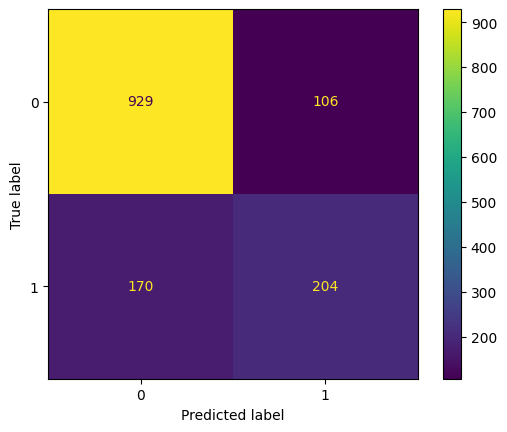

In [ ]:
ConfusionMatrixDisplay(cm).plot();

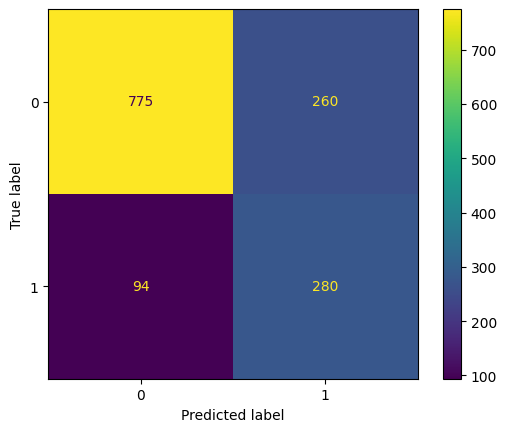

In [ ]:
threshold = 0.3
predicted = (probability >= threshold).astype(int)
cm = confusion_matrix(y_test, predicted)
ConfusionMatrixDisplay(cm).plot();

In [ ]:
# Overfitting and underfitting...